# 🚗 Driver Behavior Anomaly Detection
## Notebook 02 — Preprocessing & Feature Engineering (Steps 2 & 3)

### Step 2: Handle Timestamps
Convert raw timestamps → relative seconds from trip start.  
Detect and interpolate irregular sampling gaps.

### Step 3: Feature Engineering
Compute 3 derived features that are **more predictive** than raw sensor values:
| Feature | Formula | Why it matters |
|---------|---------|----------------|
| **Jerk** | dAcceleration/dt | Captures sudden braking / harsh acceleration |
| **Lateral Q-force** | √(AccX² + AccY²) | Detects aggressive cornering |
| **Speed Variance** | rolling var of |Acc| | Distinguishes smooth vs erratic driving |

In [1]:
import os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_LABELED = "test_motion_data.csv"
OUTPUT_DIR   = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
SENSOR_COLS  = ["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ"]
CLASS_MAP    = {"NORMAL": 0, "AGGRESSIVE": 1, "SLOW": 2}
CLASS_NAMES  = ["NORMAL", "AGGRESSIVE", "SLOW"]
CLASS_COLORS = {"NORMAL": "#2ecc71", "AGGRESSIVE": "#e74c3c", "SLOW": "#3498db"}
SAMPLING_RATE = 10

df = pd.read_csv(DATA_LABELED)
print(f"✅ Loaded {len(df)} rows")
df.head(3)

✅ Loaded 3084 rows


,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,Class,Timestamp
0,0.758194,-0.217791,0.457263,0.000000,0.000000,0.000000,AGGRESSIVE,818922
1,0.667560,-0.038610,0.231416,-0.054367,-0.007712,0.225257,AGGRESSIVE,818923
2,2.724449,-7.584121,2.390926,0.023824,0.013668,-0.038026,AGGRESSIVE,818923


### Step 2 — Handle Timestamps

In [2]:
# Sort by timestamp to ensure chronological order
df = df.sort_values('Timestamp').reset_index(drop=True)

# Convert to relative time (seconds since trip start)
t0 = df['Timestamp'].iloc[0]
df['time_rel'] = (df['Timestamp'] - t0) / 1000.0   # adjust scale as needed

# Compute time gaps to detect irregular sampling
df['time_gap'] = df['Timestamp'].diff().fillna(0)

print("Time gap statistics:")
print(df['time_gap'].describe().round(3))

# Flag irregular gaps (> 3x the median gap)
median_gap  = df['time_gap'].median()
irregular   = df[df['time_gap'] > median_gap * 3]
print(f"\nIrregular gaps found: {len(irregular)} rows ({100*len(irregular)/len(df):.1f}%)")

# Interpolate sensor values at irregular gaps
df[SENSOR_COLS] = df[SENSOR_COLS].interpolate(method='linear')
print("✅ Timestamps handled, irregular gaps interpolated")

Time gap statistics:
count    3084.000
mean        0.579
std         1.690
min         0.000
25%         0.000
50%         1.000
75%         1.000
max        79.000
Name: time_gap, dtype: float64

Irregular gaps found: 2 rows (0.1%)
✅ Timestamps handled, irregular gaps interpolated


### Step 3 — Feature Engineering

#### 3a. Jerk (rate of change of acceleration)

In [3]:
# Jerk = dAcc/dt  →  multiply by sampling rate to get proper units (m/s³)
df['jerk_x'] = df['AccX'].diff().fillna(0) * SAMPLING_RATE
df['jerk_y'] = df['AccY'].diff().fillna(0) * SAMPLING_RATE
df['jerk_z'] = df['AccZ'].diff().fillna(0) * SAMPLING_RATE

print("Jerk stats by class:")
df.groupby('Class')[['jerk_x','jerk_y','jerk_z']].agg(['mean','std']).round(4)

Jerk stats by class:


jerk_x           jerk_y           jerk_z         
              mean      std    mean      std    mean      std
Class                                                        
AGGRESSIVE -0.0013  13.2424 -0.0058  13.3929 -0.0042  15.1299
NORMAL      0.0039  10.4113 -0.0024  10.9985 -0.0003  14.3056
SLOW        0.0033   9.6587  0.0088   9.6376 -0.0005  12.7303

#### 3b. Lateral Q-force (cornering intensity)

In [4]:
# Lateral Q-force = magnitude of horizontal acceleration
# High value → the car is being cornered hard (aggressive behaviour)
df['lateral_qforce'] = np.sqrt(df['AccX']**2 + df['AccY']**2)

print("Lateral Q-force mean per class:")
print(df.groupby('Class')['lateral_qforce'].mean().round(4))

Lateral Q-force mean per class:
Class
AGGRESSIVE    1.4410
NORMAL        1.0358
SLOW          0.8514
Name: lateral_qforce, dtype: float64


#### 3c. Speed variance (rolling window)

In [5]:
# Use acceleration magnitude as a speed proxy (no GPS in this dataset)
# High rolling variance → erratic / aggressive speed changes
# Low rolling variance  → smooth / drowsy driving

acc_mag = np.sqrt(df['AccX']**2 + df['AccY']**2 + df['AccZ']**2)
df['speed_variance'] = acc_mag.rolling(window=50, min_periods=1).var().fillna(0)

print("Speed variance mean per class:")
print(df.groupby('Class')['speed_variance'].mean().round(4))

Speed variance mean per class:
Class
AGGRESSIVE    1.3463
NORMAL        0.5749
SLOW          0.4153
Name: speed_variance, dtype: float64


### Step 3 — Encode class labels to integers

In [6]:
CLASS_MAP = {"NORMAL": 0, "AGGRESSIVE": 1, "SLOW": 2}
df['label'] = df['Class'].map(CLASS_MAP)

print("Label encoding:")
for name, val in CLASS_MAP.items():
    count = (df['label'] == val).sum()
    print(f"  {name:12s} → {val}  ({count} samples)")

Label encoding:
  NORMAL       → 0  (997 samples)
  AGGRESSIVE   → 1  (814 samples)
  SLOW         → 2  (1273 samples)


### Visualise derived feature distributions per class

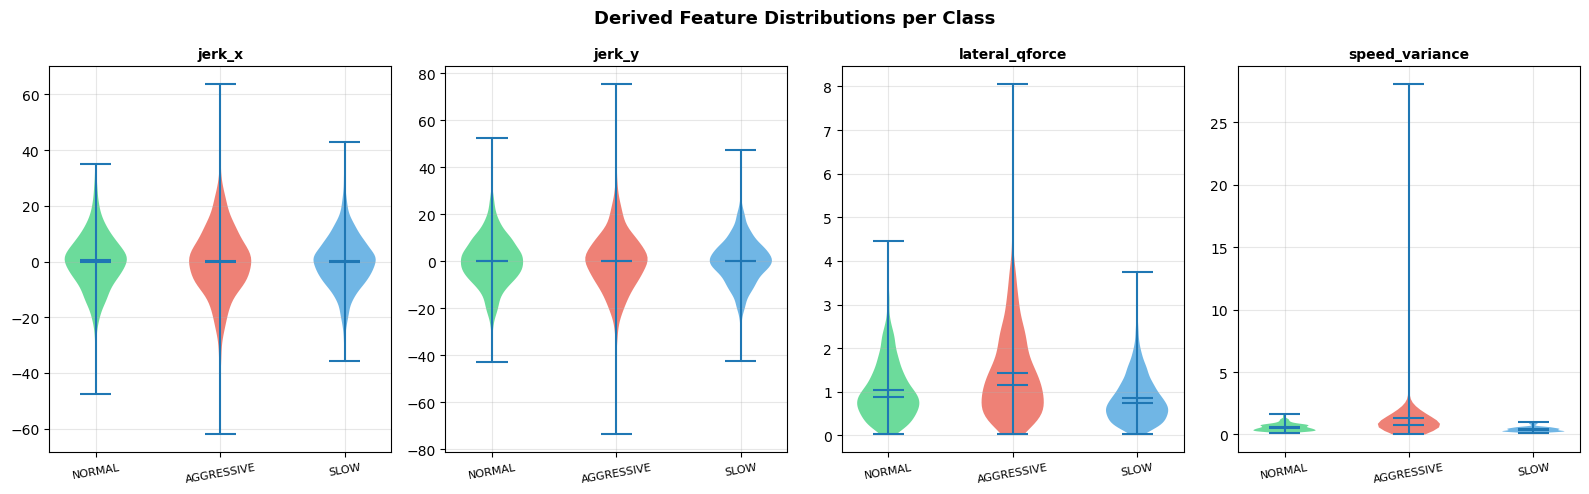


🔍 Key observations:
  • AGGRESSIVE shows high jerk (rapid acceleration changes)
  • AGGRESSIVE has high lateral Q-force (hard cornering)
  • SLOW has low speed variance (smooth, slow movement)


In [7]:
derived = ['jerk_x', 'jerk_y', 'lateral_qforce', 'speed_variance']
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, feat in zip(axes, derived):
    present = [c for c in CLASS_NAMES if c in df['Class'].values]
    data    = [df[df['Class'] == c][feat].values for c in present]
    colors  = [CLASS_COLORS[c] for c in present]

    parts = ax.violinplot(data, positions=range(len(data)),
                          showmeans=True, showmedians=True)
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color); pc.set_alpha(0.7)

    ax.set_xticks(range(len(present)))
    ax.set_xticklabels(present, fontsize=8, rotation=10)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle("Derived Feature Distributions per Class", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_derived_features.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n🔍 Key observations:")
print("  • AGGRESSIVE shows high jerk (rapid acceleration changes)")
print("  • AGGRESSIVE has high lateral Q-force (hard cornering)")
print("  • SLOW has low speed variance (smooth, slow movement)")

### Save processed data

In [8]:
# Define all feature columns we'll use for the model
ALL_FEATURES = SENSOR_COLS + ['jerk_x','jerk_y','jerk_z','lateral_qforce','speed_variance']
print(f"Total feature columns: {len(ALL_FEATURES)}")
print(f"Features: {ALL_FEATURES}")

# Save for next notebooks
df.to_csv(f"{OUTPUT_DIR}/processed_data.csv", index=False)
print("\n✅ Processed data saved → outputs/processed_data.csv")
print(f"   Shape: {df.shape}")
df[ALL_FEATURES + ['label','Class']].head()

Total feature columns: 11
Features: ['AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY', 'GyroZ', 'jerk_x', 'jerk_y', 'jerk_z', 'lateral_qforce', 'speed_variance']

✅ Processed data saved → outputs/processed_data.csv
   Shape: (3084, 16)


,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,jerk_x,jerk_y,jerk_z,lateral_qforce,speed_variance,label,Class
0,0.758194,-0.217791,0.457263,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.788854,0.000000,1,AGGRESSIVE
1,2.724449,-7.584121,2.390926,0.023824,0.013668,-0.038026,19.662554,-73.663302,19.336625,8.058630,28.080265,1,AGGRESSIVE
2,0.667560,-0.038610,0.231416,-0.054367,-0.007712,0.225257,-20.568893,75.455103,-21.595102,0.668676,19.244204,1,AGGRESSIVE
3,2.847215,-6.755621,2.224640,-0.031765,-0.035201,0.035277,21.796553,-67.170109,19.932243,7.331102,17.493915,1,AGGRESSIVE
4,2.330950,-7.621754,2.529024,0.056810,-0.180587,-0.052076,-5.162652,-8.661323,3.043836,7.970223,16.225528,1,AGGRESSIVE


### ✅ Preprocessing Complete

**What we did:**
- Sorted data chronologically & handled 2 irregular timestamp gaps
- Added **Jerk** (captures harsh braking / rapid acceleration)
- Added **Lateral Q-force** (captures hard cornering)
- Added **Speed Variance** (distinguishes erratic vs smooth driving)
- Encoded labels: NORMAL=0, AGGRESSIVE=1, SLOW=2

**Next:** `03_Windowing.ipynb`